In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [3]:
df = pd.read_csv(r"E:\lineker_enviroment\venv_machine_learning\machine_learning\projects\churn_predictor\telco_churn_data.csv")

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
# Verificamos se existem nulos
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Removemos a coluna customerID pois ela não tem nenhuma função de ajudar na previsão do modelo
df = df.drop(columns=["customerID"])

# Trocamos os valores em branco por 0.0 float na coluna Total Charges
df["TotalCharges"] = df["TotalCharges"].replace({" " : "0.0"}).astype(float)

df.shape

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Vemos a contagem de churn true = [1] e churn false =[0] 
df["Churn"].value_counts()

# Vemos a relação de desbalanceamento dividindo não churn por churn
print(f"Class Imbalance Ratio: {df['Churn'].value_counts()[0] / df['Churn'].value_counts()[1]:.2f}:1")

Class Imbalance Ratio: 2.77:1


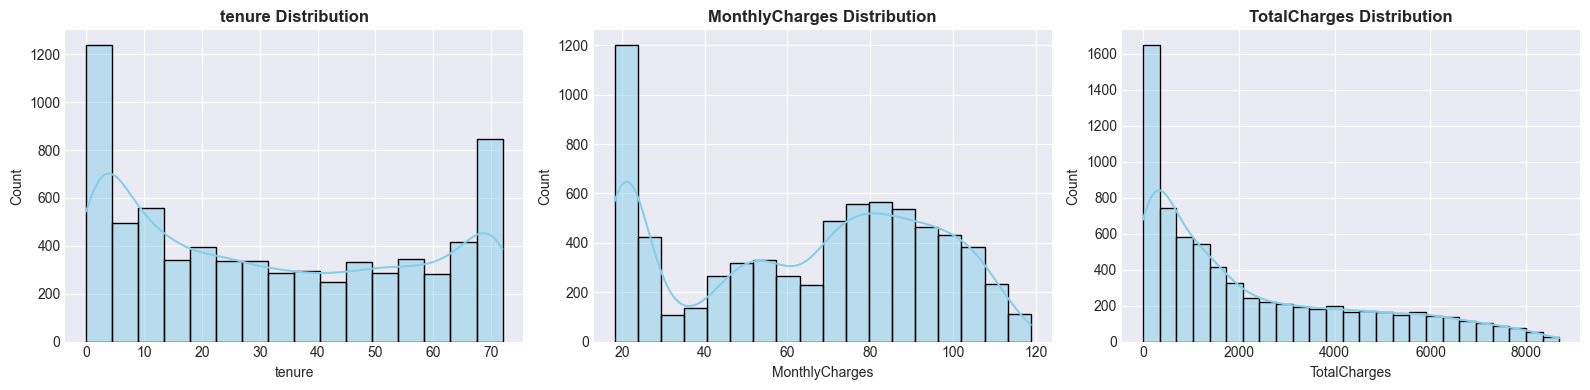

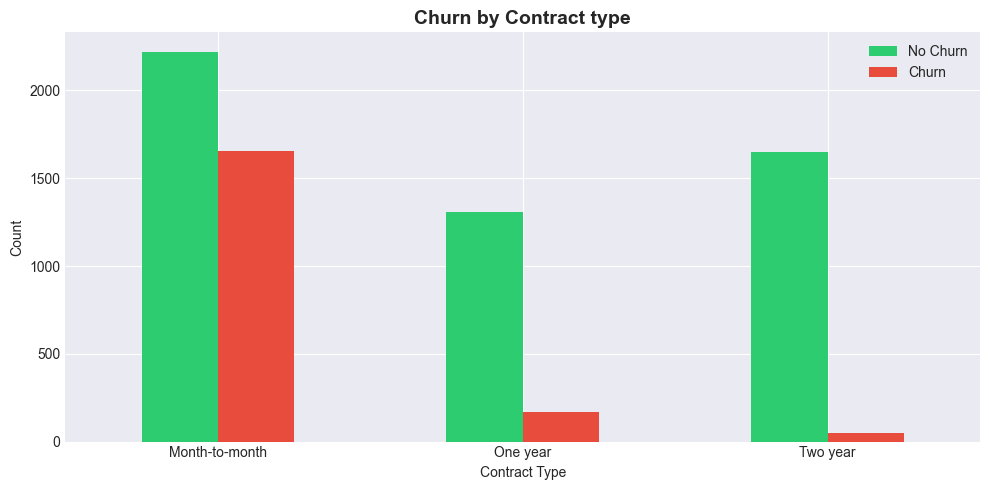

In [ ]:
# Aqui queremos ver a distribuição das colunas tenure, MonthlyCharges e TotalCharges para termos uma noção melhor no df
fig , axes = plt.subplots(1, 3, figsize=(16,4))

for idx, col in enumerate(["tenure", "MonthlyCharges","TotalCharges"]):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# O gráfico abaixo foi feito na intenção de verificar se o Churn está relacionado com o tipo de contrato
fig, ax = plt.subplots(1,1, figsize=(10, 5))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn.plot(kind='bar', stacked=False, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn by Contract type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Count')
ax.legend(['No Churn', 'Churn'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()
# Como pode ser visto no gráfico o tipo de contrato é sim uma característica muito importante para decidir se o cliente vai se tornar churn true

In [10]:
# Aqui vamos fazer o encoder das colunas binárias
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Encoder das colunas de gênero
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# Encoder das colunas categóricas
categorical_cols = ['MultipleLines','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']

encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

In [ ]:
# Aqui separamos os dados de treino e dados de teste, vamos deixar 20% dos dados para o teste
X = df.drop('Churn', axis=1)
Y = df['Churn']

# O stractify garante que a relação entre churn true [1] e churn false [0] sejam proporcionalmente iguais para ambos os dados de treino e teste no intuito de assegurar que o modelo não vai se inviezar no treino
# random_state é a seed do gerador de números aleatório, ela garante que, caso você rode o código no seu computador os dados vão ser divididos da mesma forma que no meu
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, stratify=Y, random_state=42)

x_train.shape[0]


5634

In [ ]:
# Aqui já da para ver que os dados de teste correspondem a 20% dos dados totais
x_test.shape[0]

1409

In [ ]:
# Como vimos que nosso dataset está muito desbalanceado, vamos usar o SMOTE (Synthetic Minority Over-sampling Technique) para corrigir isso
# O que o smote faz é basicamente criar dados semelhantes (mas não iguais) no intuito de balancear o df
smote = SMOTE(random_state=42)

x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)


# Antes do SMOTE
dict(y_train.value_counts())


{0: np.int64(4139), 1: np.int64(1495)}

In [ ]:
# Depois do SMOTE
dict(pd.Series(y_train_balanced).value_counts())

{0: np.int64(4139), 1: np.int64(4139)}

In [15]:
# Agora sim vamos usar o XGBooster
# n_estimator é o número de árvores
# max_depth é a profundidade que cada árvore vai ser calculada
# learning_rate é quanto cada árvore vai contribuir para o resultado final
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

xgb_model.fit(x_train_balanced, y_train_balanced)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [16]:
# Agora vamos ver a acurácia do nosso modelo
y_train_pred = xgb_model.predict(x_train)
y_test_pred = xgb_model.predict(x_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [18]:
print('Training Accuracy', train_acc)
print('Test Accuracy', test_acc)
# Como a diferença entre a acurária do treino e do teste é "pequena" significa que nosso modelo não está ficando overfiting

Training Accuracy 0.8271210507632233
Test Accuracy 0.7679205110007097


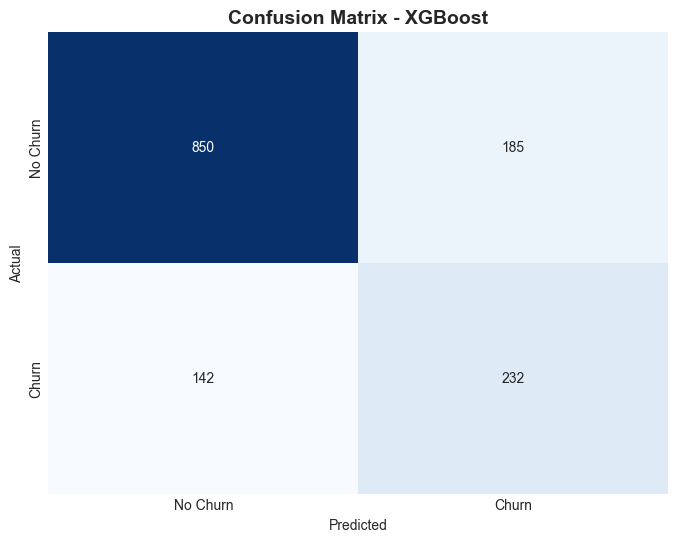

In [19]:
# Aqui vamos plotar a matriz de confusão para verificar quais são os true positives, e true negatives
# O canto Superior Esquerdo são os True Negatives
# O canto Inferior Direito são os True Positives
# O canto Superior Direito são os Flase Positives
# O canto Inferior Esquerdo são os False Negatives
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])

plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

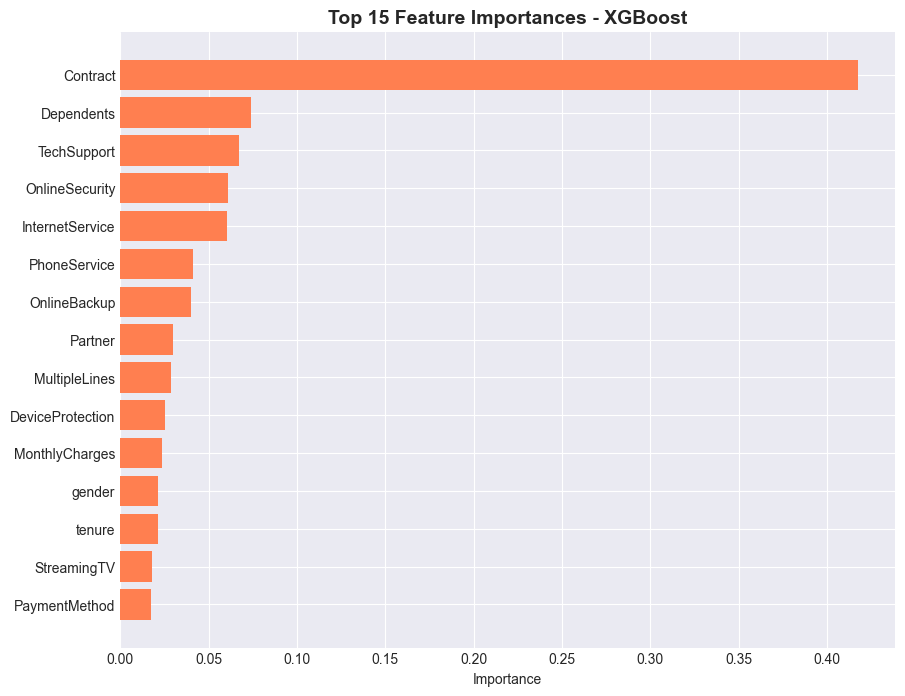

In [20]:
# Com o XGBoost conseguimos ver os features mais importantes que contribuiram na previsão de churn
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(10)

plt.figure(figsize=(10,8))

plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], color='coral')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Aqui vamos montar os arquivos .plk no intuito de dar deploy no nosso modelo. seguimos agora para o códio churn_app.py
joblib.dump(xgb_model, 'customer_churn_model.pkl')
joblib.dump(encoders, 'churn_encoders.pkl')

['churn_encoders.pkl']